# Tree Search Agent

<a target="_blank" href="https://colab.research.google.com/github/lavague-ai/LaVague/blob/main/docs/docs/get-started/quick-tour-notebook/quick-tour.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

In this notebook, we first introduce and implement an agent coupled with a Tree Search algorithm alike the A* algorithm. Finally we look at its performance on a specific web navigation task and we do the same with a simple baseline agent without Tree Search. The conclusion is that the Tree Search enabled-agent is able to backtrack and explore while the baseline agent is stuck in its past bad navigation choices.

## Pre-requisites

**Note**: We use OpenAI's models, for the embedding, LLM and Vision model. You will need to set the OPENAI_API_KEY variable in your local environment with a valid API key for this example to work.

If you don't have an OpenAI API key, please get one here: https://platform.openai.com/docs/quickstart/developer-quickstart

# Installation

We start by download LaVague.

In [1]:
!pip install lavague

We will need to set our OpenAI Key as a Colab secret (see the key icon on the left-hand side of the Colab notebook) named 'OPENAI_API_KEY' and then convert it to an environment variable with the same name.

In [2]:
import os

# Check if running in Google Colab
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
else:
    os.environ["OPENAI_API_KEY"] = os.getenv('OPENAI_API_KEY')

## ActionEngine

**An WebAgent is made up of two components: an `ActionEngine` and a `WorldModel`.**

Let's start by initializing an `ActionEngine`, which is responsible for generating automation code for text instructions and executing them.

In [3]:
from lavague.core import ActionEngine
from lavague.drivers.selenium import SeleniumDriver

selenium_driver = SeleniumDriver()
action_engine = ActionEngine(selenium_driver)

# World model

Next, we will initialize our `WorldModel`, providing it with examples of global objectives for actions and the desired thought process and reasoning we wish it to replicate to generate the next instruction that needs to be passed to the `ActionEngine`.

In [4]:
from lavague.core import WorldModel

world_model = WorldModel()

# Value Function

Next, we will initialize our `ValueFunction`, providing it with the desired thought process and reasoning we wish it to replicate to generate the score of the last action. It takes in inputs the objective, previous instructions, the last engine used and the resulting state of the action as well as the last screenshot. In the original paper ([Tree Search for Language Model Agents](https://jykoh.com/search-agents)), they use more screenshots from the action history and a different prompt.

In [5]:
from __future__ import annotations
import os
from abc import ABC
from llama_index.core import PromptTemplate
from llama_index.core.multi_modal_llms import MultiModalLLM
from llama_index.legacy.readers.file.base import SimpleDirectoryReader
from lavague.core.context import Context, get_default_context
from lavague.core.logger import AgentLogger, Loggable
from functools import lru_cache
from PIL import Image
from lavague.core.utilities.model_utils import get_model_name
import time
import yaml

import re
import numpy as np

VALUE_FUNCTION_PROMPT_TEMPLATE = PromptTemplate(
    """
You are an expert in evaluating the performance of a web navigation agent. The agent is designed to help a human user navigate a website to complete a task. Given the user's objective, the previous instructions the agent was given, the current state of the webpage, your goal is to decide whether the agent's execution is successful or not. If the current state is a failure but it looks like the agent is on the right track towards success, you should also output as such.

There are three types of tasks:
1. Information seeking: The user wants to obtain certain information from the webpage, such as the information of a product, reviews, the text in a comment or post, the date of a submission, etc. This may be formulated in the intent as "tell me", "what is", or "list out". The agent's response must contain the information the user wants, or explicitly state that the information is not available. Otherwise, e.g. the agent encounters an exception and respond with the error content, the task is considered to be a failure. It is VERY IMPORTANT that the bot response is the stop action with the correct output. If the bot response is not stop (e.g., it is click, type, or goto), it is considered a failure for information seeking tasks.
2. Site navigation: The user wants to navigate to a specific page (which may also be specified in the intent as "find", "show me", "navigate to"). Carefully examine the agent's action history and the final state of the webpage (shown in the LAST IMAGE) to determine whether the agent successfully completes the task. It is VERY IMPORTANT that the agent actually navigates to the specified page (reflected by the final state of the webpage, in the LAST IMAGE) and NOT just output the name of the item or post. Make sure that the final url is compatible with the task. For example, if you are tasked to navigate to a comment or an item, the final page and url should be that of the specific comment/item and not the overall post or search page. If asked to navigate to a page with a similar image, make sure that an image on the page is semantically SIMILAR to the intent image. If asked to look for a particular post or item, make sure that the image on the page is EXACTLY the intent image. For this type of task to be considered successful, the LAST IMAGE and current URL should reflect the correct content. No need to consider the agent's response.
3. Content modification: The user wants to modify the content of a webpage or configuration. Ensure that the agent actually commits to the modification. For example, if the agent writes a review or a comment but does not click post, the task is considered to be a failure. Carefully examine the agent's action history and the final state of the webpage to determine whether the agent successfully completes the task. No need to consider the agent's response.

Your inputs are:
- objective ('str'): a high level description of the goal to achieve.
- previous_instructions ('str'): a list of previous steps taken to reach the objective.
- last_engine ('str'): the engine used in the previous step.
- current_state ('dict'): the state of the environment in YAML to use to perform the next step.

*IMPORTANT*
Format your response into two lines as shown below:

Thoughts: <your thoughts and reasoning process>
Status: "success" or "failure"
On the right track to success: "yes" or "no"

Here is the next objective:
Objective: {objective}
Previous instructions:
{previous_instructions}
Last engine: {last_engine}
Current state:
{current_state}
{tab_info}

Thought:
"""
)


def clean_directory(path):
    # Get all the file names in the directory
    file_names = os.listdir(path)

    # Iterate over the file names and remove each file
    for file_name in file_names:
        file_path = os.path.join(path, file_name)
        if os.path.isfile(file_path):
            os.remove(file_path)


class ValueFunction(ABC, Loggable):
    """Abstract class for ValueFunction"""

    def __init__(
        self,
        mm_llm: MultiModalLLM = None,
        prompt_template: PromptTemplate = VALUE_FUNCTION_PROMPT_TEMPLATE,
        logger: AgentLogger = None,
        n: int = 20,
    ):
        if mm_llm is None:
            mm_llm = get_default_context().mm_llm
        self.mm_llm: MultiModalLLM = mm_llm
        self.prompt_template = prompt_template
        self.logger: AgentLogger = logger
        self.n = n

    def get_score(
        self,
        objective: str,
        current_state: dict,
        past: dict,
        observations: dict,
    ) -> str:
        """Use GPT*V to generate a score for the current state and objective."""
        mm_llm = self.mm_llm
        logger = self.logger

        previous_instructions = past["previous_instructions"]
        last_engine = past["last_engine"]

        tab_info = observations["tab_info"]

        try:
            current_state_str = yaml.dump(current_state, default_flow_style=False)
        except:
            raise Exception("Could not convert current state to YAML")

        screenshots_path: str = observations["screenshots_path"]
        image_documents = SimpleDirectoryReader(screenshots_path).load_data()

        prompt = self.prompt_template.format(
            objective=objective,
            previous_instructions=previous_instructions,
            last_engine=last_engine,
            current_state=current_state_str,
            tab_info=tab_info,
        )

        start = time.time()

        all_responses = []
        for _ in range(self.n):
            mm_llm_output = mm_llm.complete(
                prompt, image_documents=image_documents
            ).text
            all_responses.append(mm_llm_output)

        end = time.time()
        value_function_inference_time = end - start

        all_scores = []
        for r in all_responses:
            try:
                pred = re.search(r'Status: "?(.+)"?', r).group(1)
                if 'success' in pred.lower():
                    score = 1.0
                else:
                    # Check if it's on the path to success
                    on_path = re.search(r'On the right track to success: "?(.+)"?', r).group(1)
                    if 'yes' in on_path.lower():
                        score = 0.5
                    else:
                        score = 0.0
            except Exception as e:
                print(f"Error parsing response: {e}")
                score = 0.0

            all_scores.append(score)

        score = np.mean(all_scores).item()

        if logger:
            log = {
                "value_function_prompt": prompt,
                "Final score": score,
                "value_function_inference_time": value_function_inference_time,
                "screenshots": [
                    Image.open(image_document.image_path)
                    for image_document in image_documents
                ],
            }
            logger.add_log(log)

        return score

    def get_mm_llm_name(self):
        return get_model_name(self.mm_llm)

In [6]:
value_function = ValueFunction(n=5) # n is the number of evaluations we do before averaging

# Action Memory

An Action object to store all the information of a navigation trajectory in memory.

In [7]:
"""TODO: Make this class generalizable"""

from lavague.core.logger import AgentLogger, Loggable


class Action(Loggable):
    """
    Short term memory module of the agent.
    """

    def __init__(self, user_data=None, logger: AgentLogger = None) -> None:
        current_state = {
            "external_observations": {
                "vision": "[SCREENSHOT]",
            },
            "internal_state": {
                "user_inputs": [],
                "agent_outputs": [],
            },
        }
        self.logger = logger

        if user_data:
            current_state["internal_state"]["user_inputs"].append(user_data)

        self.current_state = current_state

        self.previous_instructions: str = "[NONE]"
        self.last_instruction: str = ""
        self.last_engine: str = "[NONE]"
        self.code_trajectory: str = ""
        self.value: int = 0.5

    def __lt__(self, other):
        return self.value > other.value # Done on purpose because heapq is a min-heap and not a max-heap as we want...

    def set_user_data(self, user_data=None):
        if user_data:
            self.current_state["internal_state"]["user_inputs"].append(user_data)

    def get_state(self):
        current_state = self.current_state
        past = {
            "previous_instructions": str(self.previous_instructions),
            "last_engine": self.last_engine,
        }

        logger = self.logger

        if logger:
            log = {
                "current_state": current_state,
                "past": past,
            }
            logger.add_log(log)
        return current_state, past

    def get_last_instruction(self):
        return self.last_instruction
    def get_last_engine(self):
        return self.last_engine
    def get_code(self):
        return self.code_trajectory
    def get_value(self):
        return self.value


    def update_instruction(self, instruction):
        if self.previous_instructions == "[NONE]":
            self.previous_instructions = f"""
- {instruction}"""
        else:
            self.previous_instructions += f"""
- {instruction}"""
        self.last_instruction = instruction
    def update_current_state(self, output):
        if output:
            self.current_state["internal_state"]["agent_outputs"].append(output)
    def update_last_engine(self, last_engine):
        self.last_engine = last_engine
    def update_code(self, last_code):
        self.code_trajectory += last_code
    def update_value(self, value):
        self.value = value


# TreeAgent Definition

First, we need to fix the extract_next_engine() function by adding re.IGNORECASE to avoid case sensitivity...

In [8]:
DEFAULT_ENGINES: list[str] = [
    "Navigation Controls",
    "Python Engine",
    "Navigation Engine",
    "COMPLETE",
]

def extract_next_engine(text: str, next_engines: list[str] = DEFAULT_ENGINES) -> str:
    # Use a regular expression to find the content after "Next engine:"

    next_engine_patterns = [r"Next engine:\s*(.*)", r"### Next Engine:\s*(.*)"]

    for pattern in next_engine_patterns:
        next_engine_match = re.search(pattern, text, re.IGNORECASE)
        if next_engine_match:
            extracted_text = next_engine_match.group(1).strip()
            # To avoid returning a non-existent engine

            for engine in next_engines:
                if engine.lower() in extracted_text.lower():
                    return engine

    raise ValueError(f"No next engine found in the text: {text}")

Now, we can define the TreeAgent class that will be used later. It does not yet support gradio demo, etc...

Moreover, add_next_actions() does not implement self-consistency contrarily to the original paper ([Tree Search for Language Model Agents](https://jykoh.com/search-agents)) because the generated next actions are not diversed enough to make it useful.

In [9]:
from io import BytesIO
import logging
import os
import copy
import heapq
import shutil
from typing import Any, Optional

from lavague.core.action_engine import ActionEngine
from lavague.core.world_model import WorldModel

from lavague.core.utilities.format_utils import (
    extract_before_next_engine,
    extract_world_model_instruction,
    replace_hyphens,
)
from lavague.core.logger import AgentLogger, LocalDBLogger
from lavague.core.base_driver import BaseDriver
from lavague.core.base_engine import ActionResult
from lavague.core.utilities.telemetry import send_telemetry
from PIL import Image
from IPython.display import display, HTML, Code
from lavague.core.token_counter import TokenCounter
from lavague.core.utilities.config import is_flag_true

logging_print = logging.getLogger(__name__)
logging_print.setLevel(logging.INFO)
format = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
ch = logging.StreamHandler()
ch.setLevel(logging.INFO)
ch.setFormatter(format)
logging_print.addHandler(ch)
logging_print.propagate = False


class TreeAgent:
    """
    Web agent class, for now only works with selenium.
    """

    def __init__(
        self,
        world_model: WorldModel,
        action_engine: ActionEngine,
        value_function: ValueFunction,
        token_counter: Optional[TokenCounter] = None,
        n_steps: int = 10,
        branching_factor: int = 3,
        clean_screenshot_folder: bool = True,
        logger: AgentLogger = None,
    ):
        self.driver: BaseDriver = action_engine.driver
        self.action_engine: ActionEngine = action_engine
        self.world_model: WorldModel = world_model
        self.value_function: ValueFunction = value_function
        self.token_counter = token_counter
        self.interrupted = False

        self.n_steps = n_steps
        self.branching_factor = branching_factor

        self.output = ""

        self.clean_screenshot_folder = clean_screenshot_folder

        if logger is None:
            self.logger: AgentLogger = AgentLogger()
        else:
            self.logger = logger

        self.action_engine.set_logger_all(self.logger)
        self.world_model.set_logger(self.logger)
        self.value_function.set_logger(self.logger)

        init_action = Action()
        init_action.set_logger(self.logger)
        self.action_queue = []
        heapq.heappush(self.action_queue, init_action)
        self.url = ""

        if self.clean_screenshot_folder:
            try:
                if os.path.isdir("screenshots"):
                    shutil.rmtree("screenshots")
                logging_print.info("Screenshot folder cleared")
            except:
                pass

        self.result = ActionResult(
            instruction=None,
            code=self.driver.code_for_init(),
            success=False,
            output=None,
            total_estimated_tokens=0,
            total_estimated_cost=0.0,
        )

    def get(self, url):
        self.url = url
        self.driver.get(url)
        self.driver.wait_for_idle()
        self.result.code += self.driver.code_for_get(url) + "\n"


    def add_next_actions(self, objective: str, action: Action) -> Optional[ActionResult]:
        obs = self.driver.get_obs()
        current_state, past = action.get_state()

        for _ in range(self.branching_factor):
            world_model_output = self.world_model.get_instruction(
                objective, current_state, past, obs
            )
            logging_print.info(world_model_output)
            next_engine_name = extract_next_engine(world_model_output)
            instruction = extract_world_model_instruction(world_model_output)
            new_action = copy.deepcopy(action)
            new_action.update_last_engine(next_engine_name)
            new_action.update_instruction(instruction)
            if new_action.get_last_engine() == "COMPLETE" or new_action.get_last_engine() == "SUCCESS":
                return self.termination(new_action)
            heapq.heappush(self.action_queue, new_action)

    def termination(self, action: Action) -> ActionResult:
        self.result.success = True
        self.result.output = action.get_last_instruction()
        self.result.code += action.get_code()
        logging_print.info("Objective reached. Stopping...")
        return self.result

    def take_action_and_score(self, objective: str, action: Action) -> Optional[Action]:
        next_engine_name = action.get_last_engine()
        instruction = action.get_last_instruction()
        action_result = self.action_engine.dispatch_instruction(
            next_engine_name, instruction
        )
        if action_result.success:
            action.update_current_state(action_result.output)
            action.update_code(action_result.code)

            obs = self.driver.get_obs()
            current_state, past = action.get_state()
            score = self.value_function.get_score(objective, current_state, past, obs)
            action.update_value(score)

            return action

        return None

    def run_step(self, objective: str) -> Optional[ActionResult]:
        # Select best action to do:
        best_action = heapq.heappop(self.action_queue)

        # Navigate to be in the right state to perform the action
        self.driver.get(self.url)
        if best_action.get_code() != "":
          self.driver.exec_code(best_action.get_code())

        # Take action and score
        best_action = self.take_action_and_score(objective, best_action)
        if best_action == None:
            return None

        # Add next actions to the queue
        obs = self.driver.get_obs()
        result = self.add_next_actions(objective, best_action)

        #self.logger.add_log(obs)

        self.process_token_usage()
        self.logger.end_step()
        return result

    def prepare_run(self, display: bool = False, user_data=None):
        self.action_engine.set_display_all(display)
        if user_data:
            init_action = heapq.heappop(self.action_queue)
            init_action.set_user_data(user_data)
            heapq.heappush(self.action_queue, init_action)
        self.logger.new_run()

    def run(
        self,
        objective: str,
        user_data=None,
        display: bool = False,
        log_to_db: bool = is_flag_true("LAVAGUE_LOG_TO_DB"),
        step_by_step=False,
    ) -> ActionResult:
        self.interrupted = False
        self.prepare_run(display=display, user_data=user_data)
        # Add next actions to the root queue
        init_action = heapq.heappop(self.action_queue)
        self.add_next_actions(objective, init_action)
        try:
            for _ in range(self.n_steps):
                result = self.run_step(objective)
                if result is not None:
                    break

                if step_by_step:
                    input("Press ENTER to continue")

        except KeyboardInterrupt:
            logging_print.warning("The agent was interrupted.")
            self.interrupted = True
            pass
        except Exception as e:
            logging_print.error(f"Error while running the agent: {e}")
            self.interrupted = True
            raise e
        finally:
            origin = self.origin if hasattr(self, "origin") else "lavague"
            send_telemetry(self.logger.return_pandas(), origin=origin)
            if log_to_db:
                local_db_logger = LocalDBLogger()
                local_db_logger.insert_logs(self)
        return self.result

    def process_token_usage(self):
        if self.token_counter is not None:
            token_counts, token_costs = self.token_counter.process_token_usage(
                self.world_model, self.action_engine, result_to_update=self.result
            ) # self.value_function could be added
            self.logger.add_log(token_counts)
            self.logger.add_log(token_costs)

    def display_previous_nodes(self, steps: int) -> None:
        """prints out all nodes per each sub-instruction for given steps"""
        dflogs = self.logger.return_pandas()
        # check if dflogs are not null and not empty and engine_log is present in dflogs columns
        if (
            dflogs is not None
            and dflogs.empty is False
            and "engine_log" in dflogs.columns
        ):
            if steps > len(dflogs):
                print(
                    f"Previous steps: {len(dflogs)}\nrequested steps: {steps}\nshowing available steps"
                )
            steps = len(dflogs) if steps > len(dflogs) else steps
            for step in range(steps):
                print(f"Step: {step}")
                sub_ins = 0
                if isinstance(dflogs.at[step, "engine_log"], list):
                    for subinst in dflogs.at[step, "engine_log"]:
                        print(f"Sub-Instruction: {sub_ins}")
                        sub_ins += 1
                        x = 0
                        for node in subinst["retrieved_html"]:
                            print(f"Node {x}")
                            x = x + 1
                            display(HTML(node))  # Display node as visual element
                            display(Code(node, language="html"))  # Display code
        else:
            print(
                f"No previous nodes available. Please run the agent atleast once to view previous steps"
            )

    def display_all_nodes(self) -> None:
        """prints out all nodes per each sub-instruction"""
        dflogs = self.logger.return_pandas()
        # check if dflogs are not null and not empty and engine_log is present in dflogs columns
        if (
            dflogs is not None
            and dflogs.empty is False
            and "engine_log" in dflogs.columns
        ):
            print(f"Number of steps: {len(dflogs)}")
            steps = len(dflogs)
            for step in range(steps):
                print(f"Step: {step}")
                sub_ins = 0
                if isinstance(dflogs.at[step, "engine_log"], list):
                    for subinst in dflogs.at[step, "engine_log"]:
                        print(f"Sub-Instruction: {sub_ins}")
                        sub_ins += 1
                        x = 0
                        for node in subinst["retrieved_html"]:
                            print(f"Node: {x}")
                            x = x + 1
                            display(HTML(node))  # Display node as visual element
                            display(Code(node, language="html"))  # Display code
        else:
            print(
                f"No previous nodes available. Please run the agent atleast once to view previous steps"
            )

    def set_origin(self, origin: str):
        self.origin = origin

# Tree Agent Demo

In [14]:
agent = TreeAgent(world_model, action_engine, value_function, branching_factor=3)

2025-01-16 12:11:53,565 - INFO - Screenshot folder cleared


In [15]:
agent.get("https://huggingface.co/models")

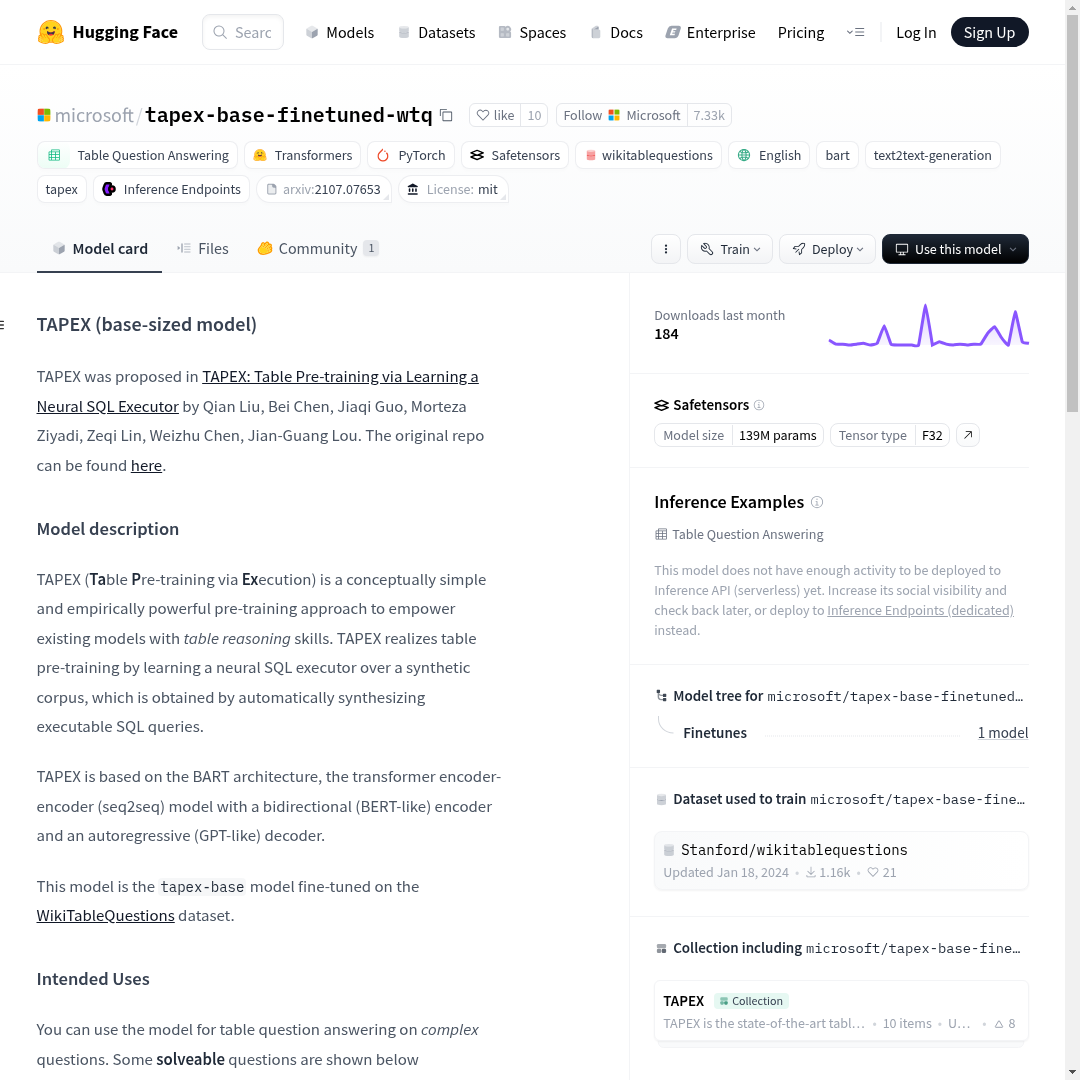

2025-01-16 12:14:37,395 - INFO - Thoughts:
- The current page shows the model page for 'microsoft/tapex-base-finetuned-wtq' on Hugging Face.
- The objective is to find a model for question answering with tabular data.
- The current model seems to be suitable for the task as it is specifically fine-tuned for tabular question answering.
- The objective has been achieved as the model details are visible.

Next engine: COMPLETE
Instruction: The model 'microsoft/tapex-base-finetuned-wtq' is suitable for question answering with tabular data.
2025-01-16 12:14:37,402 - INFO - Objective reached. Stopping...


ActionResult(instruction=None, code='from selenium import webdriver\nfrom selenium.webdriver.common.by import By\nfrom selenium.webdriver.chrome.options import Options\nfrom selenium.webdriver.common.keys import Keys\nfrom selenium.webdriver.common.action_chains import ActionChains\nfrom lavague.core.base_driver import JS_SETUP_GET_EVENTS\n\nelse:\nchrome_options = Options()\nchrome_options.add_argument("--headless=new")\nuser_agent = "Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/107.0.0.0 Safari/537.36"\nchrome_options.add_argument(f"user-agent={user_agent}")\nchrome_options.add_argument("--no-sandbox")\nchrome_options.page_load_strategy = "normal"\nchrome_options.add_argument("--disable-web-security")\nchrome_options.add_argument("--disable-site-isolation-trials")\nchrome_options.set_capability("goog:loggingPrefs", {"performance": "ALL"})\n\nchrome_options.add_experimental_option("debuggerAddress", "localhost:9223")\n)\n\n# 538: browserbase imple

In [16]:
agent.run("Find a model for Question answering. I have tabular data.", display=True)

In [17]:
agent.result.code

'from selenium import webdriver\nfrom selenium.webdriver.common.by import By\nfrom selenium.webdriver.chrome.options import Options\nfrom selenium.webdriver.common.keys import Keys\nfrom selenium.webdriver.common.action_chains import ActionChains\nfrom lavague.core.base_driver import JS_SETUP_GET_EVENTS\n\nelse:\nchrome_options = Options()\nchrome_options.add_argument("--headless=new")\nuser_agent = "Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/107.0.0.0 Safari/537.36"\nchrome_options.add_argument(f"user-agent={user_agent}")\nchrome_options.add_argument("--no-sandbox")\nchrome_options.page_load_strategy = "normal"\nchrome_options.add_argument("--disable-web-security")\nchrome_options.add_argument("--disable-site-isolation-trials")\nchrome_options.set_capability("goog:loggingPrefs", {"performance": "ALL"})\n\nchrome_options.add_experimental_option("debuggerAddress", "localhost:9223")\n)\n\n# 538: browserbase implementation - move execute_cdp_cmd to 

In [18]:
agent.logger.return_pandas()

,current_state,past,world_model_prompt,world_model_output,world_model_inference_time,screenshots,engine,instruction,engine_log,success,output,code,value_function_prompt,Final score,value_function_inference_time,run_id,step
0,{'external_observations': {'vision': '[SCREENS...,"{'previous_instructions': '[NONE]', 'last_engi...",\nYou are an AI system specialized in high lev...,Thoughts:\n- The current screenshot shows the ...,2.846878,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,Click on 'Tabular Question Answering' under th...,[{'navigation_engine_input': 'Click on 'Tabula...,True,None,# Let's think step by step\n# The query asks u...,\nYou are an expert in evaluating the performa...,0.7,25.702790,db19a405-632e-4949-8e17-7b37224f8357,0
1,NaN,NaN,\nYou are an AI system specialized in high lev...,Thoughts:\n- The current screenshot shows a li...,3.356927,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,Click on the first model listed under 'Tabular...,[{'navigation_engine_input': 'Click on the fir...,True,None,# Let's think step by step\n# The query asks u...,\nYou are an expert in evaluating the performa...,0.8,14.915834,db19a405-632e-4949-8e17-7b37224f8357,1
2,NaN,NaN,\nYou are an AI system specialized in high lev...,Thoughts:\n- The current page shows the model ...,11.063644,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,** Click on 'microsoft/tapex-base-finetuned-wtq'.,[{'navigation_engine_input': '** Click on 'mic...,True,None,# Let's think step by step\n# The query asks u...,\nYou are an expert in evaluating the performa...,1.0,23.353723,db19a405-632e-4949-8e17-7b37224f8357,2


# WebAgent baseline Demo

We can also now see how the baseline `WebAgent` perform regarding the `TreeAgent` and start playing with it!

We keep the exact same simple goal and see that the baseline fails to backtrack. It shows the benefit of Tree Search agents on more difficult tasks requiring backtracking and more exploration. The TreeSearch agent should have a big edge in these situations that needs to be confirmed on a diverse set of tasks and websites.

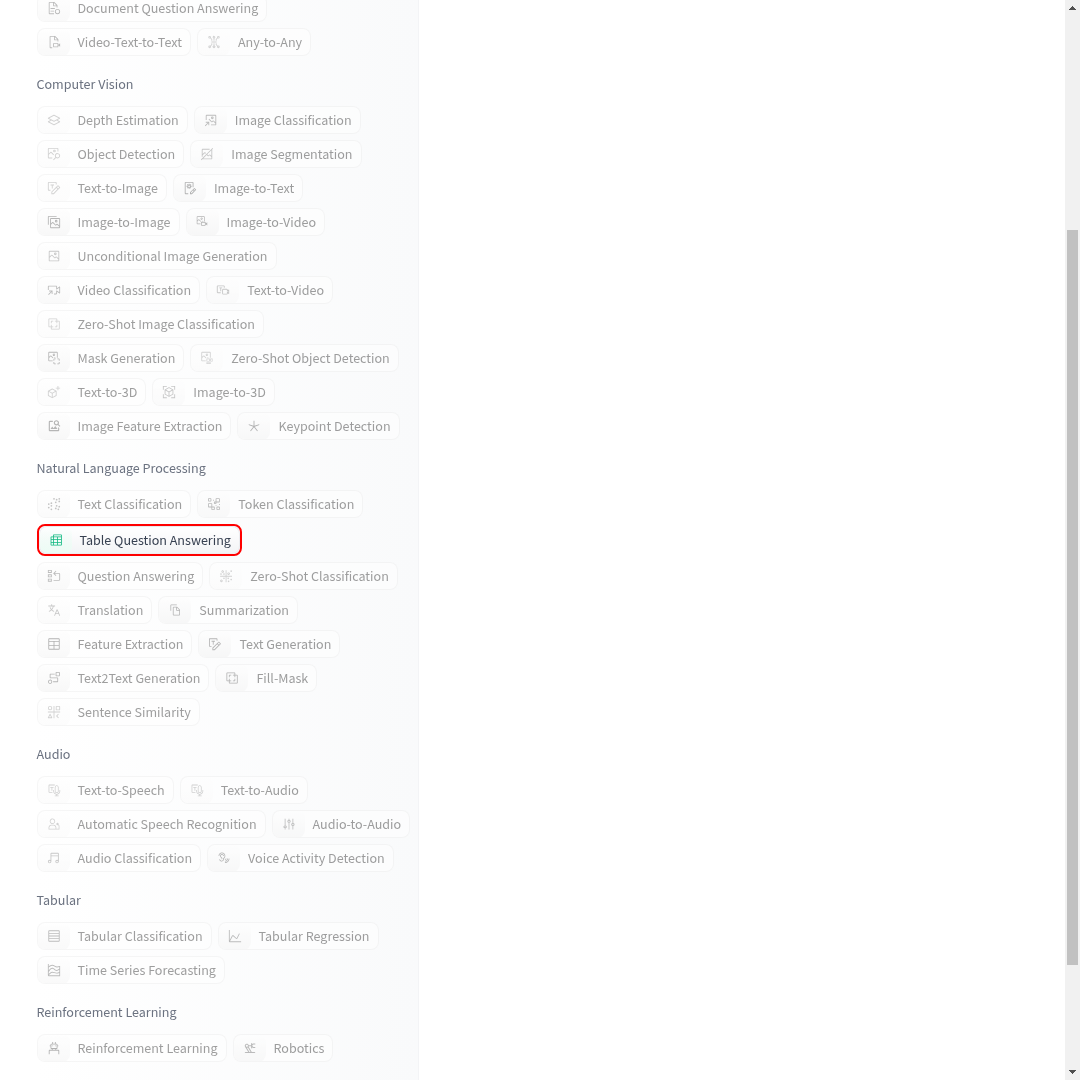

2025-01-16 12:42:55,169 - INFO - **Thoughts:**

- The current screenshot shows a list of tasks under different categories on the Hugging Face Models page.
- The objective is to find a model for question answering specifically for tabular data.
- The "Table Question Answering" option is visible under the "Natural Language Processing" section.
- Previous attempts to click on "Table Question Answering" have failed, possibly due to a technical issue or incorrect interaction.
- A new approach should be attempted to ensure the correct interaction with the element.

**Next Engine:** Navigation Engine

**Instruction:** Click on "Table Question Answering" under the "Natural Language Processing" section.
2025-01-16 12:42:55,171 - ERROR - Error while running the agent: No next engine found in the text: **Thoughts:**

- The current screenshot shows a list of tasks under different categories on the Hugging Face Models page.
- The objective is to find a model for question answering specifically for 

ValueError: No next engine found in the text: **Thoughts:**

- The current screenshot shows a list of tasks under different categories on the Hugging Face Models page.
- The objective is to find a model for question answering specifically for tabular data.
- The "Table Question Answering" option is visible under the "Natural Language Processing" section.
- Previous attempts to click on "Table Question Answering" have failed, possibly due to a technical issue or incorrect interaction.
- A new approach should be attempted to ensure the correct interaction with the element.

**Next Engine:** Navigation Engine

**Instruction:** Click on "Table Question Answering" under the "Natural Language Processing" section.

In [10]:
from lavague.core.agents import WebAgent

agent = WebAgent(world_model, action_engine)

agent.get("https://huggingface.co/models")
agent.run("Find a model for Question answering. I have tabular data.", display=True)

In [11]:
agent.result.code

'from selenium import webdriver\nfrom selenium.webdriver.common.by import By\nfrom selenium.webdriver.chrome.options import Options\nfrom selenium.webdriver.common.keys import Keys\nfrom selenium.webdriver.common.action_chains import ActionChains\nfrom lavague.core.base_driver import JS_SETUP_GET_EVENTS\n\nelse:\nchrome_options = Options()\nchrome_options.add_argument("--headless=new")\nuser_agent = "Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/107.0.0.0 Safari/537.36"\nchrome_options.add_argument(f"user-agent={user_agent}")\nchrome_options.add_argument("--no-sandbox")\nchrome_options.page_load_strategy = "normal"\nchrome_options.add_argument("--disable-web-security")\nchrome_options.add_argument("--disable-site-isolation-trials")\nchrome_options.set_capability("goog:loggingPrefs", {"performance": "ALL"})\n\nchrome_options.add_experimental_option("debuggerAddress", "localhost:9223")\n)\n\n# 538: browserbase implementation - move execute_cdp_cmd to 

In [12]:
agent.logger.return_pandas()

,current_state,past,world_model_prompt,world_model_output,world_model_inference_time,screenshots,engine,instruction,engine_log,success,output,code,html,screenshots_path,url,date,tab_info,run_id,step
0,{'external_observations': {'vision': '[SCREENS...,"{'previous_instructions': '[NONE]', 'last_engi...",\nYou are an AI system specialized in high lev...,Thoughts:\n- The current page is the Hugging F...,3.848955,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,"Click on ""Question Answering"" under the ""Tasks...","[{'navigation_engine_input': 'Click on ""Questi...",True,None,# Let's think step by step\n# The query asks u...,"<html class=""""><head>\n\t\t<meta charset=""utf-...",screenshots/8957bd8619b3e68a0ac9800671a12a64,https://huggingface.co/models,2025-01-16T12:38:40.207825,Tabs opened:\n0 - [CURRENT] Models - Hugging Face,1a81f9af-8170-46c1-ab18-f3e89d9163e6,0
1,{'external_observations': {'vision': '[SCREENS...,"{'previous_instructions': ' - Click on ""Questi...",\nYou are an AI system specialized in high lev...,- The current screenshot shows the Hugging Fac...,10.685890,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,"Click on ""Tabular"" under the ""Tasks"" section.","[{'navigation_engine_input': 'Click on ""Tabula...",True,None,# Let's think step by step\n# The query asks u...,"<html class=""""><head>\n\t\t<meta charset=""utf-...",screenshots/c33f17f65ac90567fd7d0a45fe733600,https://huggingface.co/models?pipeline_tag=que...,2025-01-16T12:38:58.108615,Tabs opened:\n0 - [CURRENT] Models - Hugging Face,1a81f9af-8170-46c1-ab18-f3e89d9163e6,1
2,{'external_observations': {'vision': '[SCREENS...,"{'previous_instructions': ' - Click on ""Questi...",\nYou are an AI system specialized in high lev...,- The current screenshot shows the Hugging Fac...,4.493757,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Controls,SCAN,None,True,None,"def get_screenshots_whole_page(self, max_s...","<html class=""""><head>\n\t\t<meta charset=""utf-...",screenshots/99e08955476d32463c5e5981ca7271e3,https://huggingface.co/models?pipeline_tag=tab...,2025-01-16T12:39:23.768067,Tabs opened:\n0 - [CURRENT] Models - Hugging Face,1a81f9af-8170-46c1-ab18-f3e89d9163e6,2
3,{'external_observations': {'vision': '[SCREENS...,"{'previous_instructions': ' - Click on ""Questi...",\nYou are an AI system specialized in high lev...,Thoughts:\n- The current screenshot shows a li...,11.586025,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,"Use the search bar to type ""question answering...",[{'navigation_engine_input': 'Use the search b...,True,None,# Let's think step by step\n# The query asks u...,"<html class=""""><head>\n\t\t<meta charset=""utf-...",screenshots/99e08955476d32463c5e5981ca7271e3,https://huggingface.co/models?pipeline_tag=tab...,2025-01-16T12:39:29.236276,Tabs opened:\n0 - [CURRENT] Models - Hugging Face,1a81f9af-8170-46c1-ab18-f3e89d9163e6,3
4,{'external_observations': {'vision': '[SCREENS...,"{'previous_instructions': ' - Click on ""Questi...",\nYou are an AI system specialized in high lev...,- The current screenshot shows the Hugging Fac...,6.623790,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,"Click on the model titled ""question answering ...",[{'navigation_engine_input': 'Click on the mod...,True,None,# Let's think step by step\n# The query asks u...,"<html class=""""><head>\n\t\t<meta charset=""utf-...",screenshots/5428f972063b87dc99b8639a40446a77,https://huggingface.co/models?pipeline_tag=tab...,2025-01-16T12:39:59.302675,Tabs opened:\n0 - [CURRENT] Models - Hugging Face,1a81f9af-8170-46c1-ab18-f3e89d9163e6,4
5,{'external_observations': {'vision': '[SCREENS...,"{'previous_instructions': ' - Click on ""Questi...",\nYou are an AI system specialized in high lev...,Thoughts:\n- The current screenshot shows a li...,6.369037,[<PIL.PngImagePlugin.PngImageFile image mode=R...,Navigation Engine,"Click on ""Table Question Answering"" under the ...","[{'navigation_